In [78]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import seaborn as sns

In [79]:
# Load dataset
df_fl = pd.read_csv('dataset_flights.csv')

print(df_fl.describe())
df_fl.info()
df_fl.head(1000)

                  ID      duration     days_left          price
count   48458.000000  48515.000000  48503.000000   48524.000000
mean   150161.419270     12.237091     25.953158   20995.059620
std     86878.647706      7.187038     13.591365   22752.525385
min         1.000000      0.830000      1.000000    1105.000000
25%     74756.500000      6.830000     14.000000    4783.000000
50%    150173.000000     11.250000     26.000000    7433.000000
75%    225423.000000     16.170000     38.000000   42521.000000
max    300147.000000     45.830000     49.000000  123071.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                48458 non-null  float64
 1   airline           48507 non-null  object 
 2   flight            48507 non-null  object 
 3   source_city       48502 non-null  object 
 4   departure_time    48526 non-

,ID,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,95430.0,Air_India,AI-9517,Bangalore,Evening,two_or_more,Night,Mumbai,Economy,5.08,10.0,13264.0
1,123622.0,AirAsia,I5-588,Kolkata,Afternoon,one,Late_Night,Delhi,Economy,11.83,27.0,3014.0
2,273244.0,Air_India,AI-768,Kolkata,Afternoon,one,Night,Chennai,Business,8.08,16.0,55983.0
3,268852.0,Vistara,UK-776,Kolkata,Evening,one,Early_Morning,Bangalore,Business,14.25,27.0,52287.0
4,231038.0,Vistara,UK-958,Mumbai,Afternoon,one,Night,Bangalore,Business,10.25,14.0,54608.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,193152.0,Indigo,6E-591,Chennai,Morning,one,Night,Mumbai,Economy,8.92,44.0,1830.0
996,84856.0,AirAsia,I5-722,Bangalore,Late_Night,zero,Late_Night,Delhi,Economy,2.92,6.0,7905.0
997,NaN,GO_FIRST,G8-7549,Delhi,Afternoon,one,Late_Night,Chennai,Economy,9.25,41.0,3869.0
998,249270.0,Air_India,AI-804,Bangalore,NaN,one,Night,Mumbai,Business,15.08,9.0,54684.0


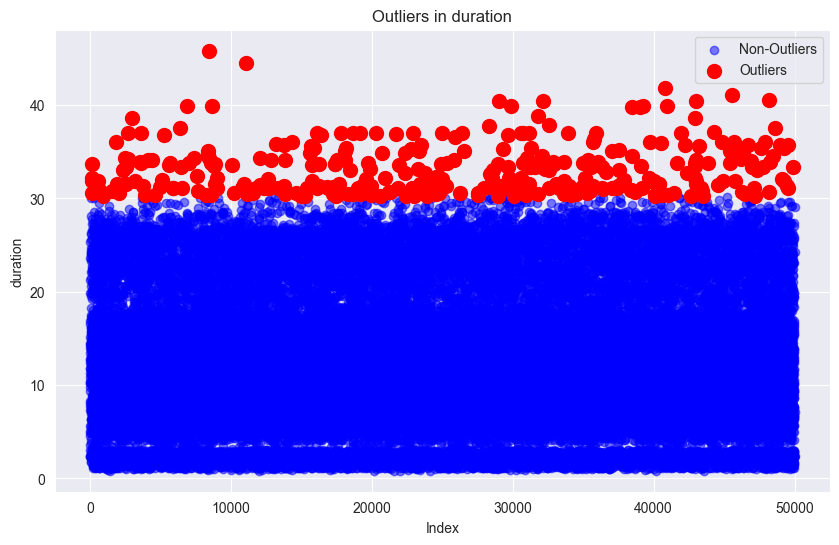

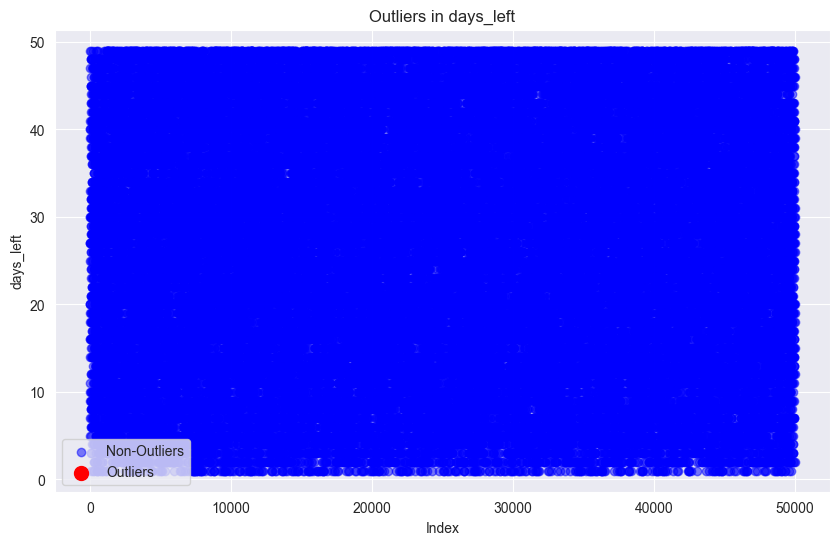

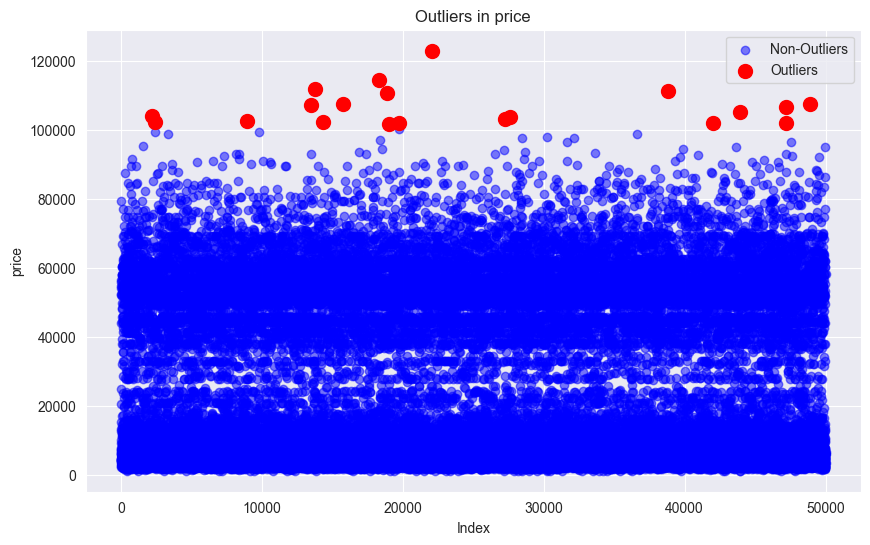

In [80]:

# Remove identifier columns
df_fl.drop(['ID'], axis=1, inplace=True)


def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

numeric_columns = ['duration', 'days_left', 'price']

for column in numeric_columns:
    outliers = detect_outliers(df_fl, column)
    df_fl = df_fl.drop(outliers.index)
    
    plt.figure(figsize=(10,6))
    plt.scatter(df_fl.index, df_fl[column], color='blue', label='Non-Outliers', alpha=0.5)
    plt.scatter(outliers.index, outliers[column], color='red', label='Outliers', s=100)
    plt.title(f'Outliers in {column}')
    plt.xlabel("Index")
    plt.ylabel(column)
    plt.legend()
    plt.show()



In [81]:

print(df_fl.describe())
print(df_fl.duplicated().sum())

# Remove null values and duplicates
df_fl.dropna(inplace=True)
df_fl.drop_duplicates(inplace=True)

# Zoznam stĺpcov pre jednotlivé typy enkódovania
label_cols = ['stops']
onehot_cols = ['departure_time', 'arrival_time', 'class']
target_cols = ['airline', 'source_city', 'destination_city', 'flight']

df = df_fl.copy()

# 1. Label Encoding pre stĺpce `stops` a `class`
label_encoder = LabelEncoder()
for col in label_cols:
    df[col] = label_encoder.fit_transform(df[col])

# 2. One-Hot Encoding pre stĺpce `departure_time` a `arrival_time`
df = pd.get_dummies(df, columns=onehot_cols, drop_first=False)

# 3. Target Encoding pre `airline`, `source_city`, `destination_city`, `flight`
for col in target_cols:
    # Vytvorenie mapy, ktorá pre každú kategóriu priradí priemernú cenu
    mean_price = df.groupby(col)['price'].mean()
    
    # Nahradenie kategórií priemernými hodnotami ceny
    df[col] = df[col].map(mean_price)
    
print(df.head(1000))

           duration     days_left          price
count  48161.000000  48159.000000   48176.000000
mean      12.091275     25.977097   20994.890921
std        6.993247     13.582312   22725.583659
min        0.830000      1.000000    1105.000000
25%        6.830000     14.000000    4759.000000
50%       11.250000     26.000000    7425.000000
75%       16.080000     38.000000   43165.000000
max       30.170000     49.000000  100204.000000
36
           airline        flight   source_city  stops  destination_city  \
0     23909.357385   5407.963636  21713.321325      1      21579.362181   
1      4125.800104   4155.870968  22216.045101      0      18395.621649   
2     23909.357385  29597.416667  22216.045101      0      21864.853586   
3     30237.895515  32886.083969  22216.045101      0      21444.935949   
4     30237.895515  27745.404580  20842.251870      0      21444.935949   
...            ...           ...           ...    ...               ...   
1376  30237.895515  30066.11155

In [82]:
print(len(df.axes[1]))
print(len(df_fl.axes[1]))

22
11


Rozhodovací strom - tréningová množina:
MSE: 26963955.521556817
RMSE: 5192.682882822406
R²: 0.9477653911764832

Rozhodovací strom - testovacia množina:
MSE: 26303025.701882016
RMSE: 5128.647550951617
R²: 0.9481011876036072


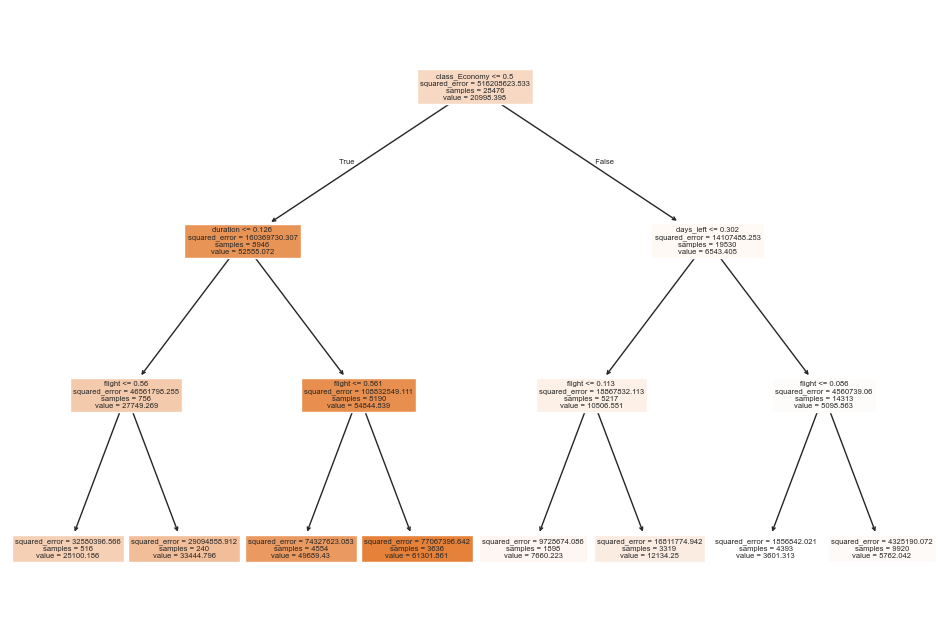

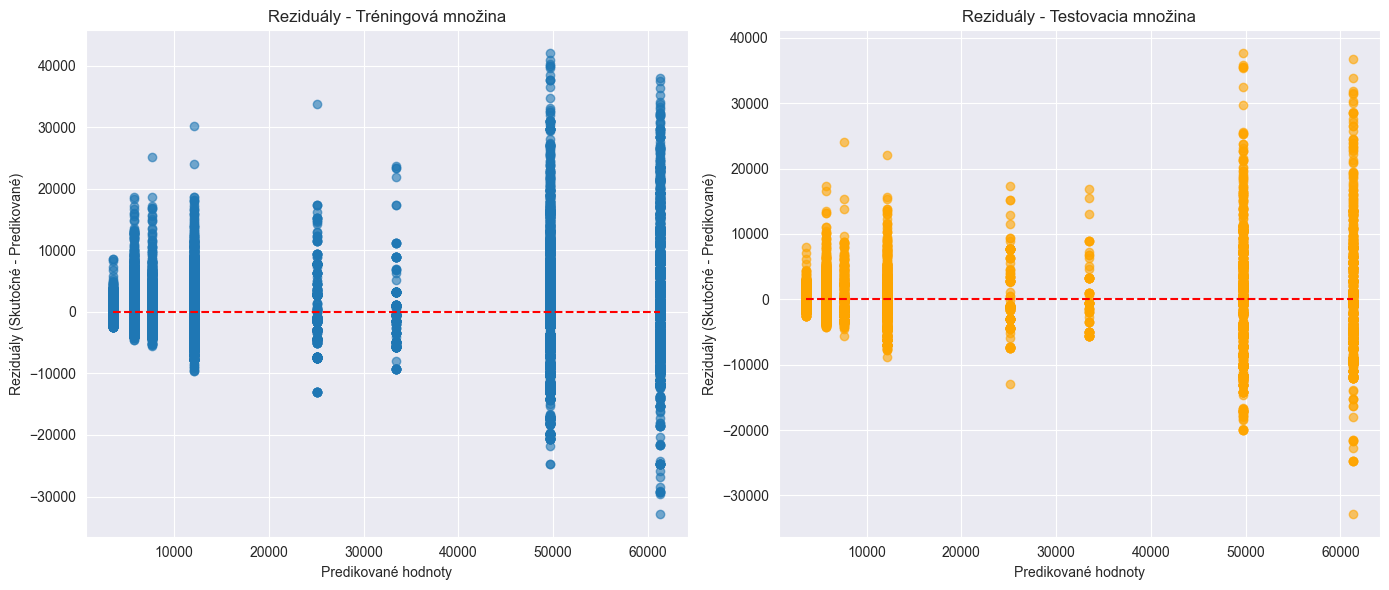

In [83]:
# Rozdelenie na vstupy (X) a cieľ (y)
X = df.drop('price', axis=1)
y = df['price']

# Rozdelenie dát na trénovaciu a testovaciu množinu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizácia vstupných hodnôt
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Tréning rozhodovacieho stromu
tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

# Hodnotenie rozhodovacieho stromu
y_pred_train = tree_model.predict(X_train)
y_pred_test = tree_model.predict(X_test)
# print(f"Train R2: {r2_score(y_train, y_pred_train)}")
# print(f"Test R2: {r2_score(y_test, y_pred_test)}")

mse_train_tree = mean_squared_error(y_train, y_pred_train)
mse_test_tree = mean_squared_error(y_test, y_pred_test)

rmse_train_tree = np.sqrt(mse_train_tree)
rmse_test_tree = np.sqrt(mse_test_tree)

print("Rozhodovací strom - tréningová množina:")
print(f"MSE: {mse_train_tree}\nRMSE: {rmse_train_tree}\nR²: {r2_score(y_train, y_pred_train)}\n")
print("Rozhodovací strom - testovacia množina:")
print(f"MSE: {mse_test_tree}\nRMSE: {rmse_test_tree}\nR²: {r2_score(y_test, y_pred_test)}")

# Vizualizácia stromu
plt.figure(figsize=(12,8))
plot_tree(tree_model, filled=True, feature_names=X.columns)
plt.show()

# Reziduály pre tréningovú a testovaciu množinu
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

# Vizualizácia reziduálov pre tréningovú a testovaciu množinu
plt.figure(figsize=(14, 6))

# Reziduály na tréningovej množine
plt.subplot(1, 2, 1)
plt.scatter(y_pred_train, residuals_train, alpha=0.6)
plt.hlines(0, min(y_pred_train), max(y_pred_train), colors='r', linestyles='dashed')
plt.xlabel("Predikované hodnoty")
plt.ylabel("Reziduály (Skutočné - Predikované)")
plt.title("Reziduály - Tréningová množina")

# Reziduály na testovacej množine
plt.subplot(1, 2, 2)
plt.scatter(y_pred_test, residuals_test, alpha=0.6, color="orange")
plt.hlines(0, min(y_pred_test), max(y_pred_test), colors='r', linestyles='dashed')
plt.xlabel("Predikované hodnoty")
plt.ylabel("Reziduály (Skutočné - Predikované)")
plt.title("Reziduály - Testovacia množina")

plt.tight_layout()
plt.show()

Random Forest - Tréningová množina:
R²: 0.9976206830872051
MSE: 1228223.9085019177
RMSE: 1108.2526374892675

Random Forest - Testovacia množina:
R²: 0.9847178505163748
MSE: 7745201.712471803
RMSE: 2783.0202501009226


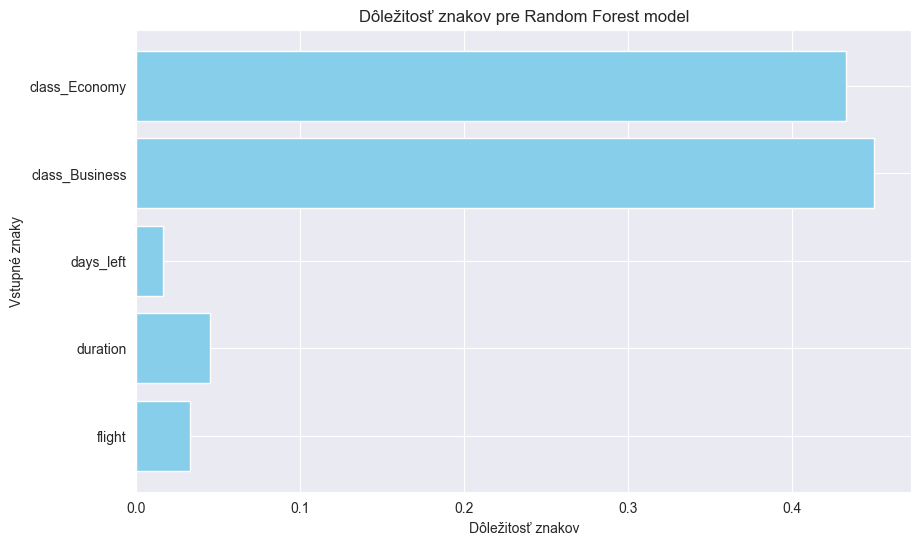

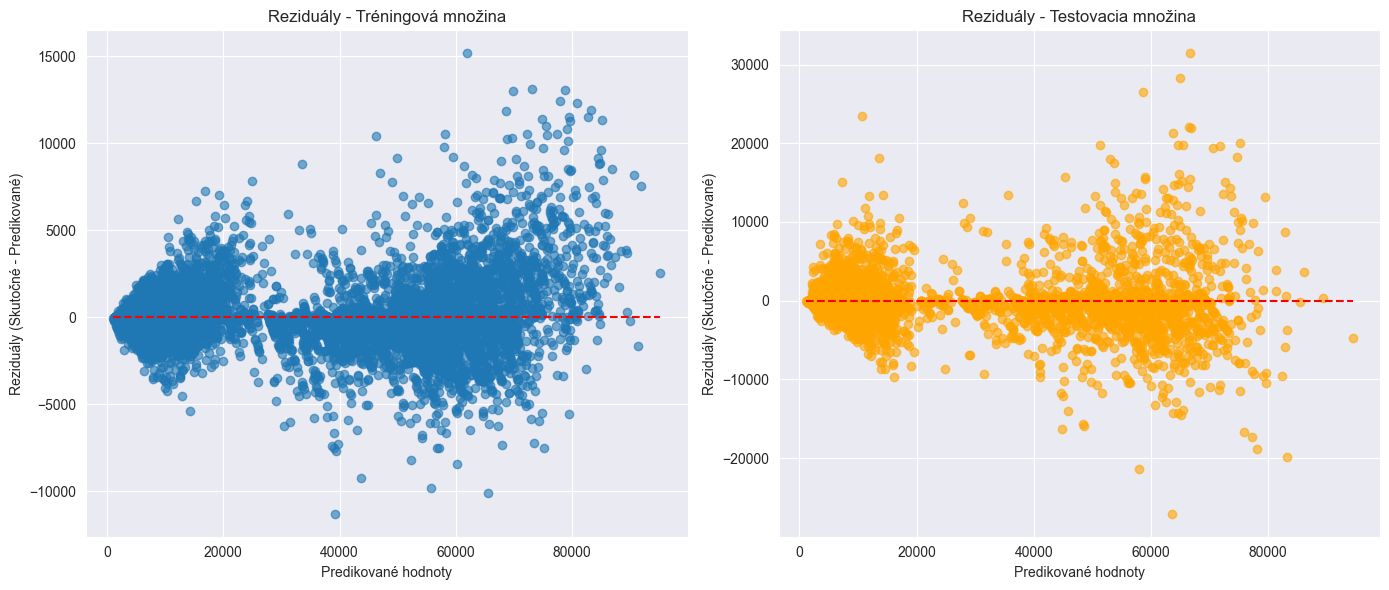

In [84]:
# Rozdelenie na vstupy (X) a cieľ (y)
X = df.drop('price', axis=1)
y = df['price']

# Rozdelenie dát na trénovaciu a testovaciu množinu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### pre lepsiu interpretaciu dat nebudeme normalizovat vstupne hodnoty (tip pre strom)
# Normalizácia vstupných hodnôt
# scaler = MinMaxScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

# Tréning Random Forest (ensemble model)
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Predikcie na tréningovej a testovacej množine
y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)

# Výpočet R² a MSE pre tréningovú množinu
r2_train = r2_score(y_train, y_pred_rf_train)
mse_train = mean_squared_error(y_train, y_pred_rf_train)
rmse_train_tree = np.sqrt(mse_train)

# Výpočet R² a MSE pre testovaciu množinu
r2_test = r2_score(y_test, y_pred_rf_test)
mse_test = mean_squared_error(y_test, y_pred_rf_test)
rmse_test_tree = np.sqrt(mse_test)

# Výpis výsledkov
print("Random Forest - Tréningová množina:")
print(f"R²: {r2_train}")
print(f"MSE: {mse_train}")
print(f"RMSE: {rmse_train_tree}")
print("\nRandom Forest - Testovacia množina:")
print(f"R²: {r2_test}")
print(f"MSE: {mse_test}")
print(f"RMSE: {rmse_test_tree}")

# Vizualizácia dôležitosti znakov
# importances = rf_model.feature_importances_
# plt.figure(figsize=(10, 6))
# plt.barh(X.columns, importances)
# plt.xlabel("Dôležitosť znakov")
# plt.ylabel("Vstupné znaky")
# plt.title("Dôležitosť znakov pre Random Forest model")
# plt.show()

feature_importances = pd.DataFrame({'feature': X.columns, 'importance': rf_model.feature_importances_})

# Filtrovanie dôležitých príznakov (napr. dôležitosť > 0.01)
important_features = feature_importances[feature_importances['importance'] > 0.01]

# Vykreslenie grafu pre filtrované príznaky
plt.figure(figsize=(10, 6))
plt.barh(important_features['feature'], important_features['importance'], color='skyblue')
plt.xlabel("Dôležitosť znakov")
plt.ylabel("Vstupné znaky")
plt.title("Dôležitosť znakov pre Random Forest model")
plt.show()



# rezidualy
# Reziduály pre tréningovú a testovaciu množinu
residuals_train = y_train - y_pred_rf_train
residuals_test = y_test - y_pred_rf_test

# Vizualizácia reziduálov pre tréningovú a testovaciu množinu
plt.figure(figsize=(14, 6))

# Reziduály na tréningovej množine
plt.subplot(1, 2, 1)
plt.scatter(y_pred_rf_train, residuals_train, alpha=0.6)
plt.hlines(0, min(y_pred_rf_train), max(y_pred_rf_train), colors='r', linestyles='dashed')
plt.xlabel("Predikované hodnoty")
plt.ylabel("Reziduály (Skutočné - Predikované)")
plt.title("Reziduály - Tréningová množina")

# Reziduály na testovacej množine
plt.subplot(1, 2, 2)
plt.scatter(y_pred_rf_test, residuals_test, alpha=0.6, color="orange")
plt.hlines(0, min(y_pred_rf_test), max(y_pred_rf_test), colors='r', linestyles='dashed')
plt.xlabel("Predikované hodnoty")
plt.ylabel("Reziduály (Skutočné - Predikované)")
plt.title("Reziduály - Testovacia množina")

plt.tight_layout()
plt.show()

SVM Train R2: 0.9519791384632981
SVM Test R2: 0.9527921934240722
SVR - Tréningová množina:
R²: 0.9519791384632981
MSE: 24788782.83471544
RMSE: 4978.833481320242

SVR - Testovacia množina:
R²: 0.9527921934240722
MSE: 23925559.995712142
RMSE: 4891.376084059796


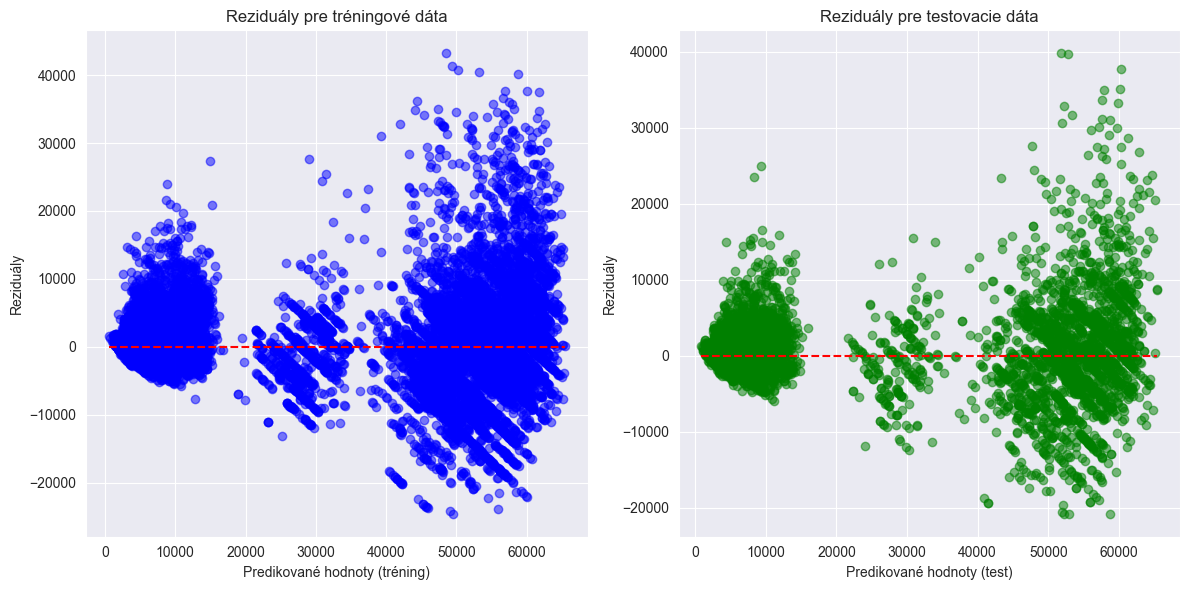

In [85]:
# Rozdelenie na vstupy (X) a cieľ (y)
X = df.drop('price', axis=1)
y = df['price']

# Rozdelenie dát na trénovaciu a testovaciu množinu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizácia vstupných hodnôt
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Tréning SVM
svr_model = SVR(C=1000)
svr_model.fit(X_train, y_train)

# Predikcie na tréningových a testovacích dátach
y_pred_svr_train = svr_model.predict(X_train)
y_pred_svr_test = svr_model.predict(X_test)

# Výpočet R² skóre
r2_train_svr = r2_score(y_train, y_pred_svr_train)
r2_test_svr = r2_score(y_test, y_pred_svr_test)
print(f"SVM Train R2: {r2_train_svr}")
print(f"SVM Test R2: {r2_test_svr}")

# Výpočet MSE a RMSE pre tréningové a testovacie dáta
mse_train_svr = mean_squared_error(y_train, y_pred_svr_train)
rmse_train_svr = np.sqrt(mse_train_svr)
mse_test_svr = mean_squared_error(y_test, y_pred_svr_test)
rmse_test_svr = np.sqrt(mse_test_svr)

print("SVR - Tréningová množina:")
print(f"R²: {r2_train_svr}")
print(f"MSE: {mse_train_svr}")
print(f"RMSE: {rmse_train_svr}")
print("\nSVR - Testovacia množina:")
print(f"R²: {r2_test_svr}")
print(f"MSE: {mse_test_svr}")
print(f"RMSE: {rmse_test_svr}")


# Vykreslenie reziduálov pre tréningové a testovacie dáta
residuals_train = y_train - y_pred_svr_train
residuals_test = y_test - y_pred_svr_test

plt.figure(figsize=(12, 6))

# Reziduály pre tréningovú množinu
plt.subplot(1, 2, 1)
plt.scatter(y_pred_svr_train, residuals_train, color='blue', alpha=0.5)
plt.hlines(0, min(y_pred_svr_train), max(y_pred_svr_train), colors='red', linestyles='dashed')
plt.xlabel("Predikované hodnoty (tréning)")
plt.ylabel("Reziduály")
plt.title("Reziduály pre tréningové dáta")

# Reziduály pre testovaciu množinu
plt.subplot(1, 2, 2)
plt.scatter(y_pred_svr_test, residuals_test, color='green', alpha=0.5)
plt.hlines(0, min(y_pred_svr_test), max(y_pred_svr_test), colors='red', linestyles='dashed')
plt.xlabel("Predikované hodnoty (test)")
plt.ylabel("Reziduály")
plt.title("Reziduály pre testovacie dáta")

plt.tight_layout()
plt.show()

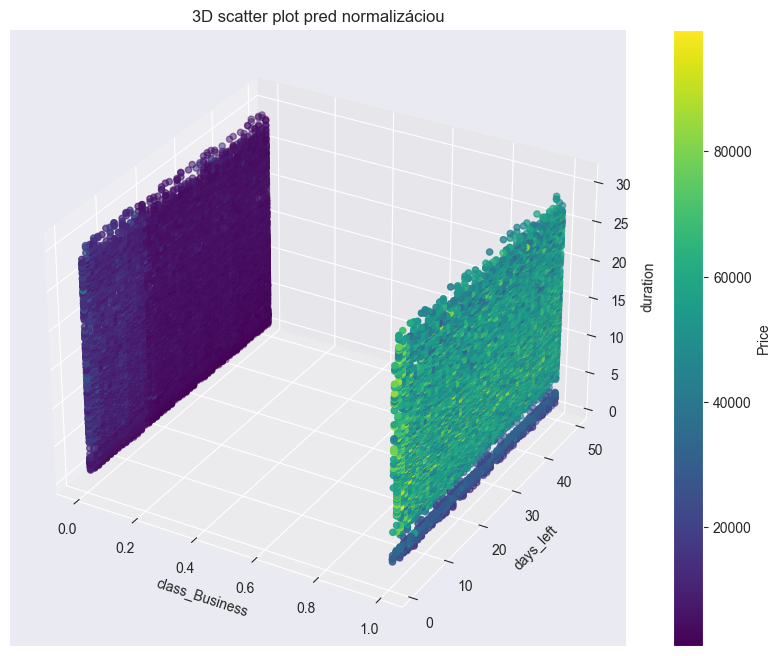

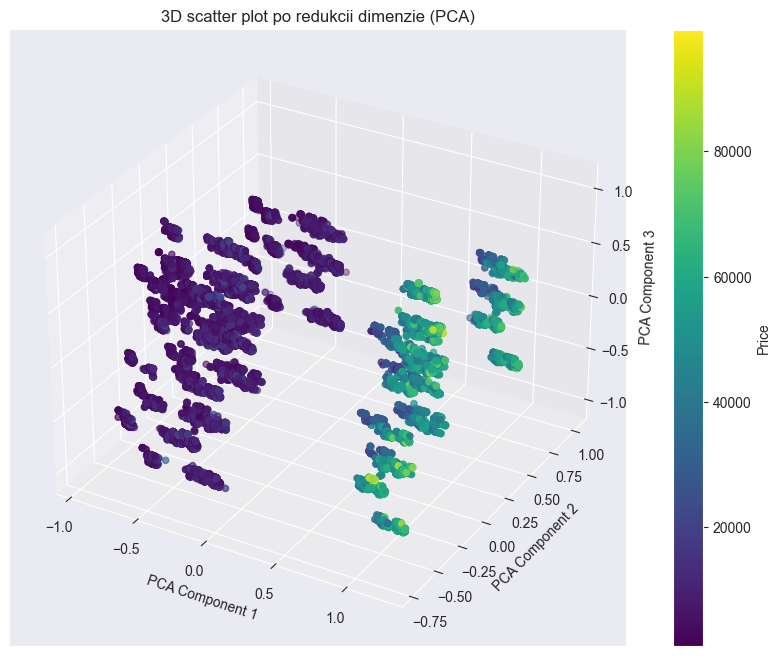

In [86]:
# Výber troch príznakov na analýzu pred normalizáciou
# feature1, feature2, feature3 = 'class_Business', 'class_Economy', 'flight'
feature1, feature2, feature3 = 'class_Business', 'days_left', 'duration'
X = df[[feature1, feature2, feature3]]
y = df['price']

# Scatter plot pred normalizáciou (farebne podľa výstupu 'price')
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X[feature1], X[feature2], X[feature3], c=y, cmap='viridis')
ax.set_xlabel(feature1)
ax.set_ylabel(feature2)
ax.set_zlabel(feature3)
plt.colorbar(sc, label='Price')
plt.title("3D scatter plot pred normalizáciou")
plt.show()

# Normalizácia všetkých príznakov pre redukciu dimenzie
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df.drop('price', axis=1))

# Redukcia dimenzie na 3 pomocou PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Scatter plot po redukcii dimenzie (farebne podľa výstupu 'price')
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y, cmap='viridis')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
plt.colorbar(sc, label='Price')
plt.title("3D scatter plot po redukcii dimenzie (PCA)")
plt.show()

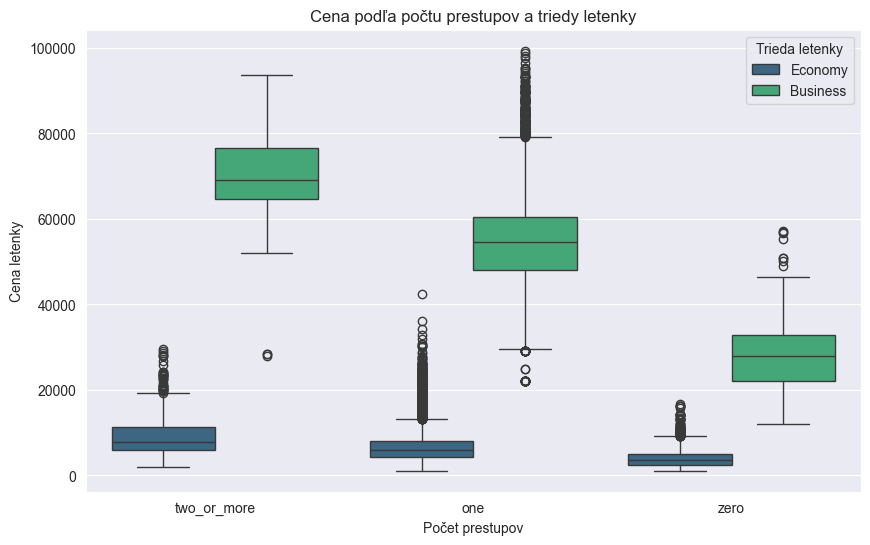

In [87]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_fl, x='stops', y='price', hue='class', palette='viridis')
plt.xlabel("Počet prestupov")
plt.ylabel("Cena letenky")
plt.title("Cena podľa počtu prestupov a triedy letenky")
plt.legend(title="Trieda letenky")
plt.show()


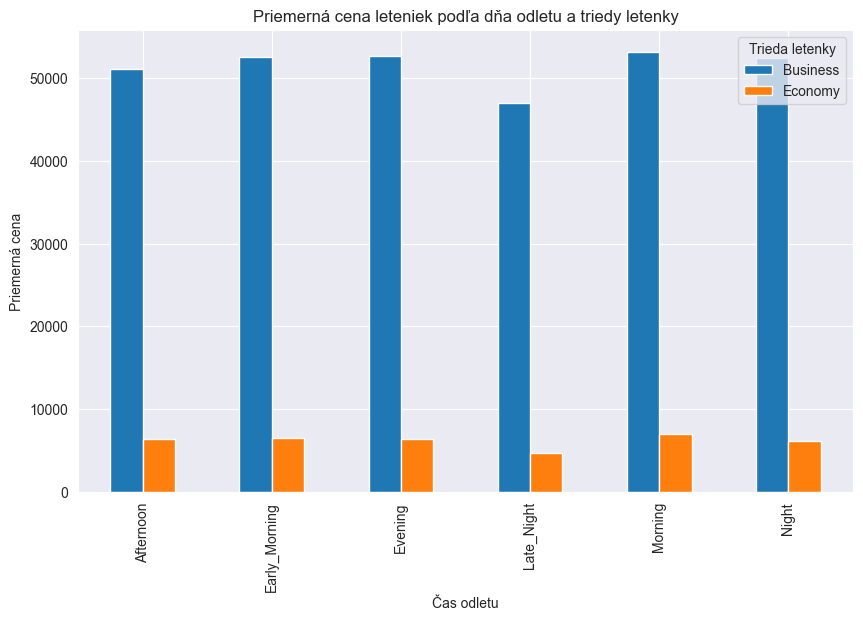

In [88]:
avg_price = df_fl.groupby(['departure_time', 'class'])['price'].mean().unstack()
avg_price.plot(kind='bar', figsize=(10, 6))
plt.xlabel("Čas odletu")
plt.ylabel("Priemerná cena")
plt.title("Priemerná cena leteniek podľa dňa odletu a triedy letenky")
plt.legend(title="Trieda letenky")
plt.show()


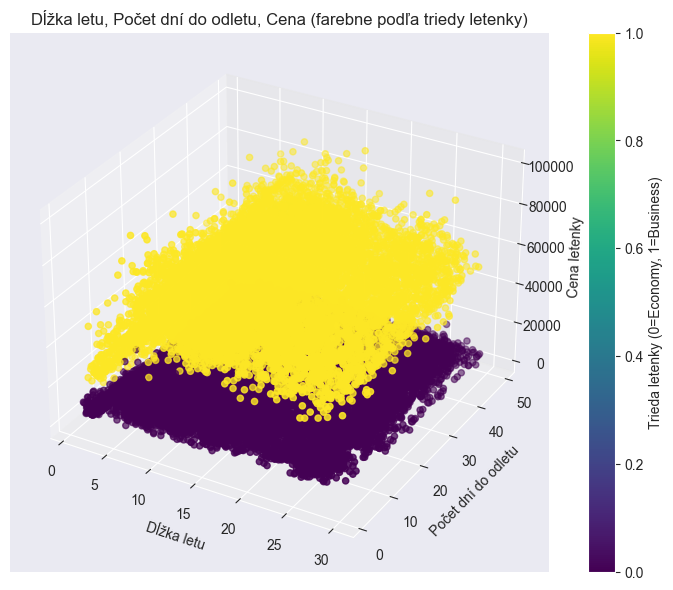

In [89]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(df_fl['duration'], df_fl['days_left'], df_fl['price'], c=df_fl['class'].apply(lambda x: 1 if x == 'Business' else 0), cmap='viridis')
ax.set_xlabel("Dĺžka letu")
ax.set_ylabel("Počet dní do odletu")
ax.set_zlabel("Cena letenky")
plt.colorbar(sc, label="Trieda letenky (0=Economy, 1=Business)")
plt.title("Dĺžka letu, Počet dní do odletu, Cena (farebne podľa triedy letenky)")
plt.show()




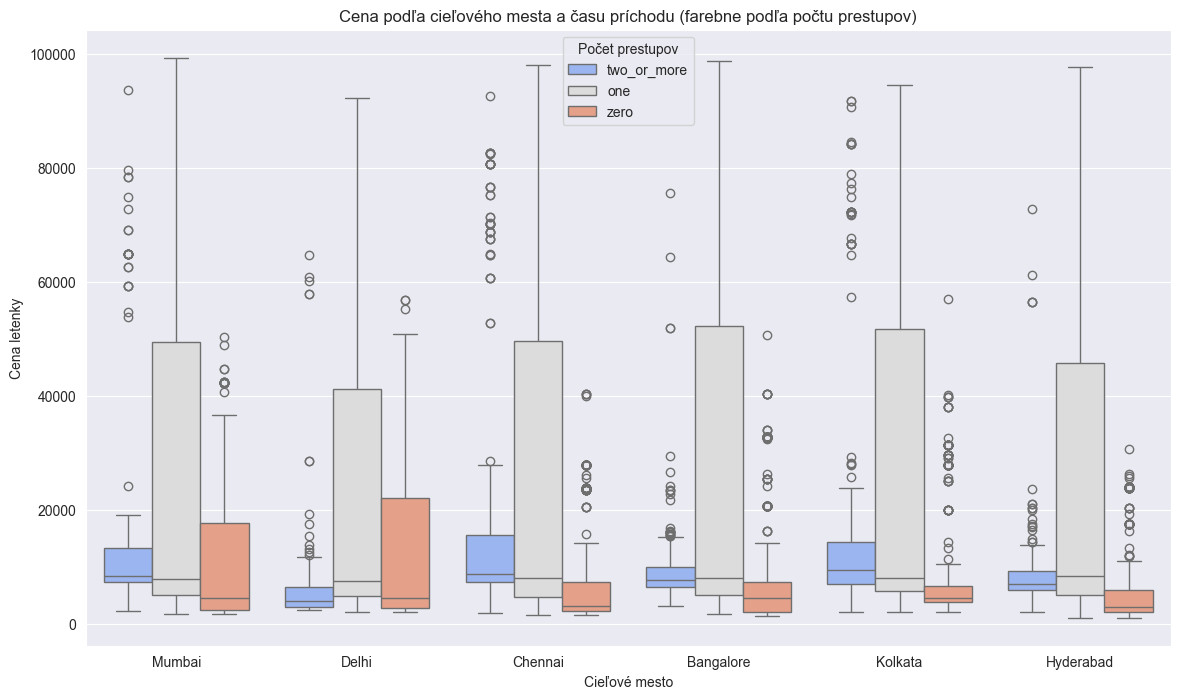

In [90]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_fl, x='destination_city', y='price', hue='stops', palette='coolwarm')
plt.xlabel("Cieľové mesto")
plt.ylabel("Cena letenky")
plt.title("Cena podľa cieľového mesta a času príchodu (farebne podľa počtu prestupov)")
plt.legend(title="Počet prestupov")
plt.show()


In [104]:
# Výpočet korelačnej matice
correlation_matrix = df.corr()

# Výber top 4 príznakov na základe korelácie s cieľom `price`
top_features_corr = correlation_matrix['price'].abs().sort_values(ascending=False).index[1:5]
X_corr = df[top_features_corr]
y = df['price']

# Rozdelenie dát na trénovaciu a testovaciu množinu
X_train_corr, X_test_corr, y_train, y_test = train_test_split(X_corr, y, test_size=0.2, random_state=42)

# Normalizácia dát
scaler = MinMaxScaler()
X_train_corr = scaler.fit_transform(X_train_corr)
X_test_corr = scaler.transform(X_test_corr)

# Tréning modelu Random Forest
rf_model_corr = RandomForestRegressor(random_state=42)
rf_model_corr.fit(X_train_corr, y_train)

# Predikcie a hodnotenie modelu
y_pred_train_corr = rf_model_corr.predict(X_train_corr)
y_pred_test_corr = rf_model_corr.predict(X_test_corr)
mse_train_corr = mean_squared_error(y_train, y_pred_train_corr)
rmse_train_corr = np.sqrt(mse_train_corr)
r2_train_corr = r2_score(y_train, y_pred_train_corr)
mse_test_corr = mean_squared_error(y_test, y_pred_test_corr)
rmse_test_corr = np.sqrt(mse_test_corr)
r2_test_corr = r2_score(y_test, y_pred_test_corr)


In [106]:
# Tréning modelu Random Forest na celej množine príznakov pre určenie dôležitosti
X = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Výber top 4 najdôležitejších príznakov
important_features = [feature for _, feature in sorted(zip(rf_model.feature_importances_, X.columns), reverse=True)][:4]
X_important = df[important_features]

# Rozdelenie dát a tréning modelu
X_train_imp, X_test_imp, y_train, y_test = train_test_split(X_important, y, test_size=0.2, random_state=42)
X_train_imp = scaler.fit_transform(X_train_imp)
X_test_imp = scaler.transform(X_test_imp)

rf_model_imp = RandomForestRegressor(random_state=42)
rf_model_imp.fit(X_train_imp, y_train)

# Predikcie a hodnotenie modelu
y_pred_train_imp = rf_model_imp.predict(X_train_imp)
y_pred_test_imp = rf_model_imp.predict(X_test_imp)
mse_train_imp = mean_squared_error(y_train, y_pred_train_imp)
rmse_train_imp = np.sqrt(mse_train_imp)
r2_train_imp = r2_score(y_train, y_pred_train_imp)
mse_test_imp = mean_squared_error(y_test, y_pred_test_imp)
rmse_test_imp = np.sqrt(mse_test_imp)
r2_test_imp = r2_score(y_test, y_pred_test_imp)



In [107]:
# Normalizácia celej množiny príznakov
X_scaled = scaler.fit_transform(X)

# PCA s cieľom zachovať aspoň 95% variancie
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# Rozdelenie dát na trénovaciu a testovaciu množinu
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Tréning modelu Random Forest na PCA dátach
rf_model_pca = RandomForestRegressor(random_state=42)
rf_model_pca.fit(X_train_pca, y_train)

# Predikcie a hodnotenie modelu
y_pred_train_pca = rf_model_pca.predict(X_train_pca)
y_pred_test_pca = rf_model_pca.predict(X_test_pca)
mse_train_pca = mean_squared_error(y_train, y_pred_train_pca)
rmse_train_pca = np.sqrt(mse_train_pca)
r2_train_pca = r2_score(y_train, y_pred_train_pca)
mse_test_pca = mean_squared_error(y_test, y_pred_test_pca)
rmse_test_pca = np.sqrt(mse_test_pca)
r2_test_pca = r2_score(y_test, y_pred_test_pca)


In [108]:
# Výpis výsledkov
print("Pôvodný model Random Forest - všetky príznaky:")
print(f"Train RMSE: {rmse_train_tree}, Test RMSE: {rmse_test_tree}")
print(f"Train R²: {r2_train}, Test R²: {r2_test}\n")

print("Model Random Forest - výber podľa korelačnej matice:")
print(f"Train RMSE: {rmse_train_corr}, Test RMSE: {rmse_test_corr}")
print(f"Train R²: {r2_train_corr}, Test R²: {r2_test_corr}\n")

print("Model Random Forest - výber podľa dôležitosti príznakov:")
print(f"Train RMSE: {rmse_train_imp}, Test RMSE: {rmse_test_imp}")
print(f"Train R²: {r2_train_imp}, Test R²: {r2_test_imp}\n")

print("Model Random Forest - výber podľa PCA:")
print(f"Train RMSE: {rmse_train_pca}, Test RMSE: {rmse_test_pca}")
print(f"Train R²: {r2_train_pca}, Test R²: {r2_test_pca}\n")


Pôvodný model Random Forest - všetky príznaky:
Train RMSE: 1108.2526374892675, Test RMSE: 2783.0202501009226
Train R²: 0.9976206830872051, Test R²: 0.9847178505163748

Model Random Forest - výber podľa korelačnej matice:
Train RMSE: 6161.339320762926, Test RMSE: 6453.015917351372
Train R²: 0.9264597674370809, Test R²: 0.9178368306408524

Model Random Forest - výber podľa dôležitosti príznakov:
Train RMSE: 2998.1443470204954, Test RMSE: 4038.2716746466526
Train R²: 0.9825867505582238, Test R²: 0.9678232055536127

Model Random Forest - výber podľa PCA:
Train RMSE: 1314.3831411041401, Test RMSE: 3385.3386784321765
Train R²: 0.9966532851973765, Test R²: 0.9773871158887999


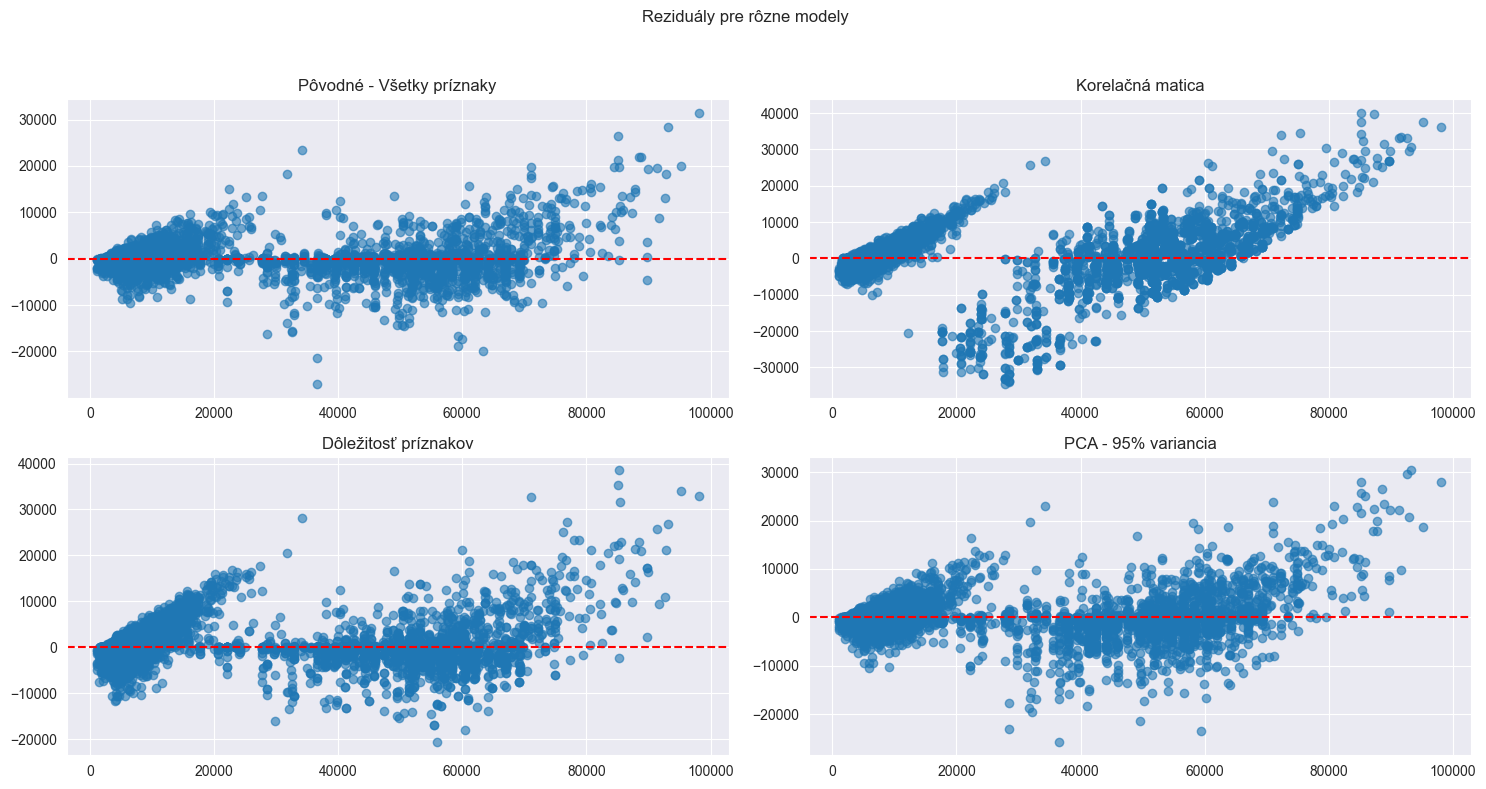

In [109]:
plt.figure(figsize=(15, 8))
plt.suptitle("Reziduály pre rôzne modely")

# Pôvodné všetky príznaky
plt.subplot(2, 2, 1)
plt.scatter(y_test, y_test - y_pred_rf_test, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Pôvodné - Všetky príznaky")

# Korelačná matica
plt.subplot(2, 2, 2)
plt.scatter(y_test, y_test - y_pred_test_corr, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Korelačná matica")

# Dôležitosť príznakov
plt.subplot(2, 2, 3)
plt.scatter(y_test, y_test - y_pred_test_imp, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Dôležitosť príznakov")

# PCA
plt.subplot(2, 2, 4)
plt.scatter(y_test, y_test - y_pred_test_pca, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("PCA - 95% variancia")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
